## Датасет Credit Card Fraud Detection.
Практический проект по построению системы поиска аномалий.

### Часть 0. Подготовка

In [1]:
# Инициализация и логирование

debug = 1  # 1 — выводить отладочные логи, 0 — скрывать

import os
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import display


In [5]:
# Полезные функции

def log(message):
    if debug == 1:
        # %Y-%m-%d — дата, %H:%M:%S — время
        timestamp = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
        print(f"[DEBUG] {timestamp} {message}")

log("Функция log готова. Использование: log(message), будет отображено при включенной отладке.")

def show(df):
    if df is None or df.empty:
        log("Ошибочный вызов show(): датафрейм пуст.")
        return
    df_show = df.iloc[0:5].copy()
    if 'name' in df_show.columns:
        df_show['name'] = "Данные скрыты"
    display(df_show)

log("Функция show готова. Использование: show(df), значения в столбце name будут скрыты, отображена таблица с примером наполнения.")

def load_excel_file(file_path):
    try:
        # Проверяем, является ли путь директорией (папкой)
        if os.path.isdir(file_path):
            log(f"Указан путь к папке. Ищем файлы внутри: {file_path}")
            valid_files = [f for f in os.listdir(file_path) if f.endswith(('.csv', '.xlsx', '.xls'))]
            
            if not valid_files:
                log(f"Ошибка: В папке {file_path} не найдено файлов .csv или .xlsx")
                return None
            
            # Берем первый найденный файл, как в вашем примере files[0]
            chosen_file = valid_files[0]
            log(f"Автоматически выбран файл: {chosen_file}")
            file_path = os.path.join(file_path, chosen_file)

        # ---------------------------------------------------------
        # Умное чтение с определением индекса Kaggle / тех. колонок
        # ---------------------------------------------------------
        # Читаем только первые 2 строки, чтобы быстро проверить имена колонок
        if file_path.endswith('.csv'):
            preview = pd.read_csv(file_path, nrows=2)
        else:
            preview = pd.read_excel(file_path, nrows=2)
            
        first_col = preview.columns[0]
        
        # Если первая колонка безымянная (Unnamed) или явно техническая (id, index)
        if "unnamed" in first_col.lower() or first_col.lower() in ['id', 'index', 'uuid']:
            log(f"Обнаружена индексная колонка '{first_col}'. Загружаем с index_col=0.")
            kwargs = {'index_col': 0}
        else:
            kwargs = {}

        # Финальная загрузка всего файла
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path, **kwargs)
        else:
            df = pd.read_excel(file_path, **kwargs)
        # ---------------------------------------------------------
        
        # Приводим оставшиеся колонки к нижнему регистру и убираем пробелы
        df.columns = [str(col).lower().strip() for col in df.columns]
        
        # Обрабатываем строковые значения
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.strip()
                df[col] = df[col].replace({'nan': None, 'null': None, 'None': None, '': None})
        
        log(f"Успешно загружено {len(df)} строк из файла: {file_path}")
        log(f"Колонки: {list(df.columns)}")
        return df
        
    except Exception as e:
        log(f"Ошибка при загрузке файла/папки {file_path}: {e}")
        return None

log("Функция load_excel_file готова. Использование: load_excel_file(путь к файлу). Возвращает df.")



[DEBUG] 2026-09-07T16:06:02 Функция log готова. Использование: log(message), будет отображено при включенной отладке.
[DEBUG] 2026-09-07T16:06:02 Функция show готова. Использование: show(df), значения в столбце name будут скрыты, отображена таблица с примером наполнения.
[DEBUG] 2026-09-07T16:06:02 Функция load_excel_file готова. Использование: load_excel_file(путь к файлу). Возвращает df.


In [7]:
# Функции анализа и EDA

# Определяет имя целевой переменной (автоматически или вручную)
def detect_target(df, target_col=None):
    if target_col is not None:
        target_clean = str(target_col).lower().strip()
        if target_clean in df.columns:
            log(f"Целевая переменная установлена вручную: '{target_clean}'")
            return target_clean
        else:
            log(f"Предупреждение: Указанная колонка '{target_col}' не найдена в DF.")
            
    # Ключевые слова для автоопределения
    target_keywords = ['class', 'target', 'default', 'churn', 'response', 'disposition', 'output']
    for col in df.columns:
        if col in target_keywords:
            log(f"Целевая переменная обнаружена автоматически: '{col}'")
            return col
            
    log("Целевая переменная не обнаружена.")
    return None


# Универсальный быстрый взгляд на структуру данных.  Разделяет признаки по типам и считает пропуски.
def fast_look(df, target_col=None):
    if df is None:
        return
        
    log("Запуск быстрого анализа структуры датафрейма (fast_look)...")
    total_rows = len(df)
    summary_data = []
    
    # Сначала выведем инфо о таргете, если он есть
    if target_col and target_col in df.columns:
        print("\n" + "="*25 + f" АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: {target_col.upper()} " + "="*25)
        val_counts = df[target_col].value_counts(dropna=False)
        val_pct = df[target_col].value_counts(dropna=False, normalize=True) * 100
        target_info = pd.DataFrame({'Количество': val_counts, 'Процент (%)': val_pct.round(2)})
        display(target_info)
    
    for col in df.columns:
        if col == target_col:
            continue
            
        null_count = df[col].isnull().sum()
        null_pct = (null_count / total_rows) * 100
        unique_count = df[col].nunique()
        dtype = df[col].dtype
        
        if unique_count == 2:
            feat_type = 'Бинарный'
        elif np.issubdtype(dtype, np.number):
            feat_type = 'Числовой'
        elif isinstance(dtype, pd.DatetimeTZDtype) or np.issubdtype(dtype, np.datetime64):
            feat_type = 'Дата/Время'
        else:
            feat_type = 'Текстовый/Категориальный'
            
        summary_data.append({
            'Признак': col,
            'Тип данных': str(dtype),
            'Категория': feat_type,
            'Уникальных': unique_count,
            'Пропусков (кол-во)': null_count,
            'Пропусков (%)': round(null_pct, 2)
        })
        
    summary_df = pd.DataFrame(summary_data)
    
    print("\n" + "="*25 + " СВОДНАЯ СТАТИСТИКА ПО ПРИЗНАКАМ " + "="*25)
    display(summary_df)
    
    print("\n" + "="*25 + " ОПИСАТЕЛЬНАЯ СТАТИСТИКА (ЧИСЛА) " + "="*25)
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
    if numeric_cols:
        display(df[numeric_cols].describe().T)
    
    cat_cols = [c for c in df.select_dtypes(exclude=[np.number]).columns if c != target_col]
    if len(cat_cols) > 0:
        print("\n" + "="*25 + " ОПИСАТЕЛЬНАЯ СТАТИСТИКА (КАТЕГОРИИ) " + "="*25)
        display(df[cat_cols].describe().T)


def plot_correlations(df, target_col=None):
    log("Расчет матрицы корреляций...")
    numeric_df = df.select_dtypes(include=[np.number])
    
    if numeric_df.shape[1] < 2:
        return
        
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap='coolwarm', linewidths=0.1, cbar=True)
    plt.title("Матрица корреляции числовых признаков", fontsize=14)
    plt.show()


def plot_distributions(df, target_col=None, max_cols=6):
    log(f"Построение графиков распределения...")
    # Отбираем признаки для графиков (исключая таргет)
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col][:max_cols]
    
    if len(numeric_cols) == 0:
        return
        
    nrows = (len(numeric_cols) + 1) // 2
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(14, nrows * 3.5))
    axes = axes.flatten()
    
    # Настройка группировки (hue), если таргет бинарный или категориальный (до 10 уникальных значений)
    use_hue = False
    if target_col and df[target_col].nunique() <= 10:
        use_hue = True
    
    for i, col in enumerate(numeric_cols):
        if use_hue:
            # Для сильного дисбаланса классов common_norm=False помогает увидеть форму распределения меньшинства
            sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[i], palette='Set2', common_norm=False)
        else:
            sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
            
        axes[i].set_title(f"Распределение: {col}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Запуск полного цикла первичного анализа одной командой
def run_full_eda(file_path, target_col=None):
    df = load_excel_file(file_path)
    if df is not None:
        # Пытаемся найти или подтвердить целевую переменную
        detected_target_col = detect_target(df, target_col)
        
        print("\n" + "#"*30 + " ПРИМЕР ДАННЫХ (SHOW) " + "#"*30)
        show(df)
        
        fast_look(df, target_col=detected_target_col)
        plot_correlations(df, target_col=detected_target_col)
        plot_distributions(df, target_col=detected_target_col)
        return df
    else:
        log("Не удалось запустить EDA, так как файл не загружен.")
        return None

### Часть 1. EDA и Preprocessing.

Path to dataset files: C:\Users\oevlannikov\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
[DEBUG] 2026-09-07T16:19:55 Указан путь к папке. Ищем файлы внутри: C:\Users\oevlannikov\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
[DEBUG] 2026-09-07T16:19:55 Автоматически выбран файл: creditcard.csv
[DEBUG] 2026-09-07T16:19:58 Успешно загружено 284807 строк из файла: C:\Users\oevlannikov\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv
[DEBUG] 2026-09-07T16:19:58 Колонки: ['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class']
[DEBUG] 2026-09-07T16:19:58 Целевая переменная обнаружена автоматически: 'class'

############################## ПРИМЕР ДАННЫХ (SHOW) ##############################


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


[DEBUG] 2026-09-07T16:19:58 Запуск быстрого анализа структуры датафрейма (fast_look)...

========================= АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: CLASS =========================


,Количество,Процент (%)
class,,
0,284315,99.83
1,492,0.17



========================= СВОДНАЯ СТАТИСТИКА ПО ПРИЗНАКАМ =========================


,Признак,Тип данных,Категория,Уникальных,Пропусков (кол-во),Пропусков (%)
0,time,float64,Числовой,124592,0,0.0
1,v1,float64,Числовой,275663,0,0.0
2,v2,float64,Числовой,275663,0,0.0
3,v3,float64,Числовой,275663,0,0.0
4,v4,float64,Числовой,275663,0,0.0
5,v5,float64,Числовой,275663,0,0.0
6,v6,float64,Числовой,275663,0,0.0
7,v7,float64,Числовой,275663,0,0.0
8,v8,float64,Числовой,275663,0,0.0
9,v9,float64,Числовой,275663,0,0.0



========================= ОПИСАТЕЛЬНАЯ СТАТИСТИКА (ЧИСЛА) =========================


,count,mean,std,min,25%,50%,75%,max
time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
v1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
v2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
v3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
v4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
v5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
v6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
v7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
v8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
v9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


[DEBUG] 2026-09-07T16:19:58 Расчет матрицы корреляций...


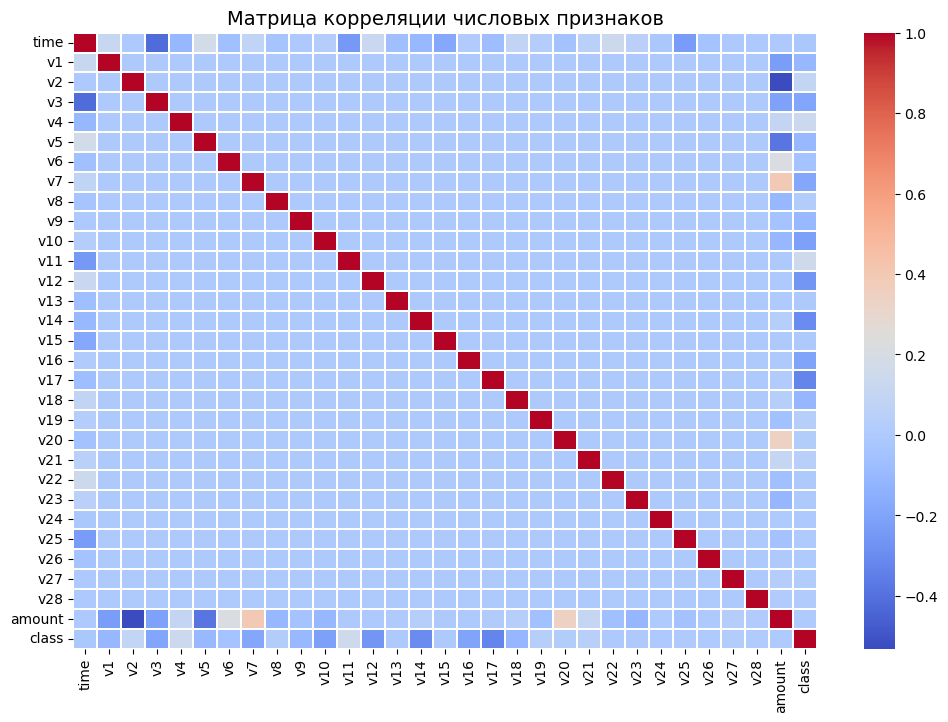

[DEBUG] 2026-09-07T16:20:00 Построение графиков распределения...


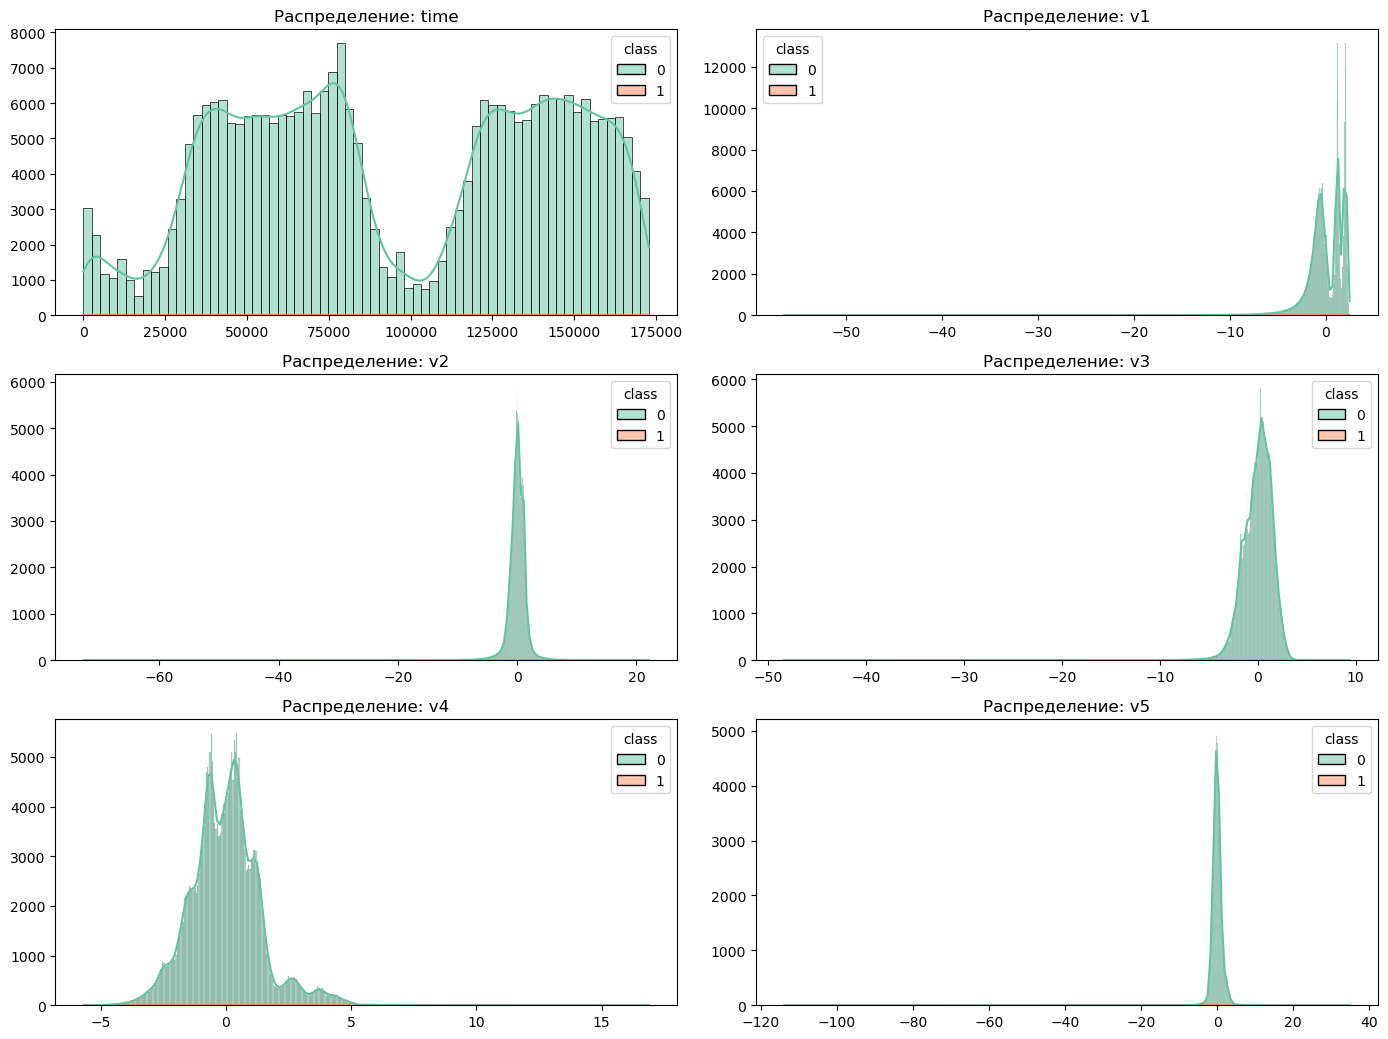

In [8]:
# Загрузка датасета
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

df = run_full_eda(path) 